In [63]:
##OLD VERSION##
import numpy as  np
from numba import njit
from itertools import product

OPEN = (6, 7, 8)

def actions_from_roll(d1, d2, d3, d4, OPEN):
    """ Returns up to 3 unique actions (dx,dy,dz) from the 3 pairings.
    OPEN must be of length 3. """
    o0, o1, o2 = OPEN
    pairings = ((d1+d2, d3+d4), (d1+d3, d2+d4), (d1+d4, d2+d3))
    acts = set()
    for s1, s2 in pairings:
        dx = (1 if s1 == 6 else 0) + (1 if s2 == 6 else 0)
        dy = (1 if s1 == 7 else 0) + (1 if s2 == 7 else 0)
        dz = (1 if s1 == 8 else 0) + (1 if s2 == 8 else 0)
        if dx + dy + dz > 0:
            acts.add((dx, dy, dz))
    return list(acts)

def precompute_actions(OPEN):
    """ Builds a padded action array of shape (1296, 3, 3) with -1 (because numba requires fixed size arrays). """
    rolls = list(product(range(1, 7), repeat=4))  # 6^4 = 1296 possible rolls with 4 dice
    R = len(rolls)
    Amax = 3
    actions = -np.ones((R, Amax, 3), dtype=np.int8) # size = 1296*3*3

    for r, (d1, d2, d3, d4) in enumerate(rolls):
        acts = actions_from_roll(d1, d2, d3, d4, OPEN)
        for k in range(min(len(acts), Amax)):
            actions[r, k, 0] = acts[k][0]
            actions[r, k, 1] = acts[k][1]
            actions[r, k, 2] = acts[k][2]

    return actions

@njit
def compute_V(Nx, Ny, Nz, actions):
    
    V = np.zeros((Nx + 1, Ny + 1, Nz + 1))
    V[Nx, Ny, Nz] = Nx + Ny + Nz

    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]

    for s in range(Smax - 1, -1, -1):
        # iterates all (x,y,z) with x+y+z = s within bounds
        
        # Nx
        x_min = max(0, s - (Ny + Nz)) # y+z = s-x 
        x_max = min(Nx, s)
        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)
            
            # Ny
            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue

                immediate_gain = x + y + z  # if we stop

                # if we keep going
                future_gain = 0.0
                for r in range(R):
                    best = 0.0  # if no admissible action, we get 0
                    for k in range(Amax):
                        dx = actions[r, k, 0]
                        if dx < 0:
                            continue
                        dy = actions[r, k, 1]
                        dz = actions[r, k, 2]
                        nx = x + dx
                        ny = y + dy
                        nz = z + dz
                        if nx <= Nx and ny <= Ny and nz <= Nz: # checks admissibility
                            val = V[nx, ny, nz]
                            if val > best:
                                best = val
                    future_gain += 1/R * best

                V[x, y, z] = immediate_gain if immediate_gain >= future_gain else future_gain

    return V



In [64]:
N6, N7, N8 = 100, 100, 100
OPEN = (6, 7, 8)
actions = precompute_actions(OPEN)
V = compute_V(N6, N7, N8, actions)
print("Le gain optimal est :", V[0, 0, 0])

Le gain optimal est : 6.330720105660973


In [1]:
## NEW VERSION WITH ACTIONS INSTEAD OF ROLLS ##
import numpy as np
from numba import njit

OPEN = (6, 7, 8)

def compute_probabilities():
    pairs = {}
    for dice1 in range(1,7):
        for dice2 in range(1,7):
            for dice3 in range(1,7):
                for dice4 in range(1,7):
                    couples_get = (
                        tuple(sorted([dice1 + dice2, dice3 + dice4])),
                        tuple(sorted([dice1 + dice3, dice2 + dice4])),
                        tuple(sorted([dice1 + dice4, dice2 + dice3]))
                    )

                    if couples_get not in pairs:
                        pairs[couples_get] = 1/(6**4)
                    else:
                        pairs[couples_get] += 1/(6**4)

    pair_keys = list(pairs.keys())
    R = len(pair_keys)

    pair_array = np.zeros((R,3,2), dtype=np.int8)
    prob_array = np.zeros(R)

    for i,k in enumerate(pair_keys):
        for j in range(3):
            pair_array[i,j,0] = k[j][0]
            pair_array[i,j,1] = k[j][1]
        prob_array[i] = pairs[k]
    #print(pair_array[22])
    return pair_array, prob_array


def actions_from_roll(pairings, OPEN):
    o0, o1, o2 = OPEN
    acts = set()
    for p1, p2 in pairings:
        dx = (1 if p1 == o0 else 0) + (1 if p2 == o0 else 0)
        dy = (1 if p1 == o1 else 0) + (1 if p2 == o1 else 0)
        dz = (1 if p1 == o2 else 0) + (1 if p2 == o2 else 0)

        if dx + dy + dz > 0:
            acts.add((dx, dy, dz))

    return list(acts)


def precompute_actions(OPEN):
    pair_array, prob_array = compute_probabilities()
    R = pair_array.shape[0]
    Amax = 3
    actions = -np.ones((R, Amax, 3), dtype=np.int8)
    for r in range(R):
        pairings = (
            tuple(pair_array[r,0]),
            tuple(pair_array[r,1]),
            tuple(pair_array[r,2])
        )
        acts = actions_from_roll(pairings, OPEN)
        if r==22:
            print(pairings, acts)

        for k in range(min(len(acts), Amax)):
            actions[r,k] = acts[k]
    return actions, pair_array, prob_array


@njit
def compute_V(Nx, Ny, Nz, actions, prob_array):

    V = np.zeros((Nx + 1, Ny + 1, Nz + 1))
    V[Nx, Ny, Nz] = Nx + Ny + Nz

    Smax = Nx + Ny + Nz
    R = actions.shape[0]
    Amax = actions.shape[1]
    policy = 1+np.zeros((Nx + 1, Ny + 1, Nz + 1, R, 3), dtype=np.int8)
    stop,continu = 0,0
    nb_1, nb_2 = 0,0
    for s in range(Smax - 1, -1, -1):
        x_min = max(0, s - (Ny + Nz))
        x_max = min(Nx, s)

        for x in range(x_min, x_max + 1):
            dif = s - x
            y_min = max(0, dif - Nz)
            y_max = min(Ny, dif)

            for y in range(y_min, y_max + 1):
                z = dif - y
                if z < 0 or z > Nz:
                    continue
                if x == Nx and y == Ny and z == Nz:
                    continue
                immediate_gain = x + y + z
                future_gain = 0.0
                for r in range(R):
                    best = 0.0
                    a_best = [-2,-2,-2]
                    for a in range(Amax):
                        dx = actions[r,a,0]
                        if dx < 0:
                            continue
                        dy = actions[r,a,1]
                        dz = actions[r,a,2]
                        nx = x + dx
                        ny = y + dy
                        nz = z + dz
                        val = V[min(nx, Nx), min(ny, Ny), min(nz, Nz)]
                        if val > best:
                            a_best[0] = actions[r,a,0]
                            a_best[1] = actions[r,a,1]
                            a_best[2] = actions[r,a,2]
                            best = val
                    #print(a_best)
                    policy[x, y, z, r, 0] = a_best[0]
                    policy[x, y, z, r, 1] = a_best[1]
                    policy[x, y, z, r, 2] = a_best[2]
                    future_gain += prob_array[r] * best
                if immediate_gain >= future_gain:
                    V[x,y,z] = immediate_gain
                    policy[x, y, z] = -1
                    stop +=1
                else:
                    V[x,y,z] = future_gain
                    continu +=1
                    #print(policy[x,y,z])
    print(policy[0,0,0,0])
    return V, policy

In [2]:
N6, N7, N8 = 10, 10, 10
OPEN = (6, 7, 8)
actions, pair_array, prob_array = precompute_actions(OPEN)
V, policy = compute_V(N6, N7, N8, actions, prob_array)
print("Le gain optimal est :", V[0, 0, 0])

((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
[-2 -2 -2]
Le gain optimal est : 6.329792304232197


In [3]:
import os 

# Fonctions pour sauvegarder et charger V et policy 
def save_arrays(V, policy, folder="data"):
    if not os.path.exists(folder):
        os.makedirs(folder)
    np.save(os.path.join(folder, "V.npy"), V)
    np.save(os.path.join(folder, "policy.npy"), policy)
    print("V et policy sauvegardés dans", folder)

def load_arrays(folder="data"):
    V_path = os.path.join(folder, "V.npy")
    policy_path = os.path.join(folder, "policy.npy")
    if os.path.exists(V_path) and os.path.exists(policy_path):
        V = np.load(V_path)
        policy = np.load(policy_path)
        print("V et policy chargés depuis", folder)
        return V, policy
    return None, None

In [4]:
def simulation_lancers(N=100):
    """Simule N lancers de 4 dés et retourne une liste de tuples (d1,d2,d3,d4)"""
    lancers = []
    for _ in range(N):
        d1, d2, d3, d4 = np.random.randint(1, 7, size=4)
        lancers.append((int(d1), int(d2), int(d3), int(d4)))
    return lancers
print(simulation_lancers(10))

[(2, 2, 4, 5), (6, 1, 4, 1), (4, 4, 3, 4), (3, 4, 5, 3), (5, 4, 6, 2), (2, 5, 6, 4), (5, 1, 5, 3), (2, 3, 2, 4), (2, 2, 4, 2), (1, 6, 1, 5)]


In [5]:
def simulation_player(lancers, policy, actions, pair_array, verbose=False): 
    x, y, z = 0, 0, 0
    for lancer in lancers:
        d1, d2, d3, d4 = lancer
        pairings = (
            tuple(sorted([d1 + d2, d3 + d4])),
            tuple(sorted([d1 + d3, d2 + d4])),
            tuple(sorted([d1 + d4, d2 + d3]))
        )
        pairings = np.array(pairings, dtype=np.int8)
        r = np.bincount(np.where(np.all(pair_array == pairings, axis=1))[0]).argmax()
        acts = actions[r]
        nb_fail = 0
        for a in range(acts.shape[0]):
            if acts[a,0] < 0:
                nb_fail += 1
        if nb_fail == acts.shape[0]:
            if verbose:
                print(pairings)
                print("No possible action, player loses")
            return 0,0,0

        lines_moved_on = policy[x, y, z, r]
        x += lines_moved_on[0]
        y += lines_moved_on[1]
        z += lines_moved_on[2]

        if verbose:
            print()
            print("Dice rolled:", lancer)
            print("Pairings:", pairings.tolist())
            print("Chosen action:", lines_moved_on.tolist())
            print("Current position:", (int(x), int(y), int(z)))

        if policy[x,y,z,0,0] == -1:
            if verbose:
                print("Player decides to stop at:", (int(x), int(y), int(z)))
            return int(x), int(y), int(z)

    return int(x), int(y), int(z)

In [74]:
V, policy = load_arrays()
if V is None or policy is None:
    print("Calcul de V et policy...")
    V, policy = compute_V(N6, N7, N8, actions, prob_array)
    save_arrays(V, policy)

Calcul de V et policy...
[-2 -2 -2]
V et policy sauvegardés dans data


In [6]:
lancer = simulation_lancers(100)
simulation_player(lancer, policy, actions, pair_array, True)


Dice rolled: (1, 3, 3, 6)
Pairings: [[4, 9], [4, 9], [6, 7]]
Chosen action: [1, 1, 0]
Current position: (1, 1, 0)
[[10 11]
 [ 9 12]
 [10 11]]
No possible action, player loses


(0, 0, 0)

In [7]:
def estimate_expected_gain(num_simulations, policy, actions, pair_array):
    total_gain = 0
    for _ in range(num_simulations):
        lancers = simulation_lancers(100)  # 100 rolls per simulation
        x, y, z = simulation_player(lancers, policy, actions, pair_array)
        total_gain += x + y + z
    return total_gain / num_simulations

# Run the simulation
num_simulations = 1000
expected_gain_sim = estimate_expected_gain(num_simulations, policy, actions, pair_array)
expected_gain_theoretical = V[0,0,0]

print(f"Estimated expected gain over {num_simulations} simulations: {expected_gain_sim:.2f}")
print(f"Theoretical expected gain from V[0,0,0]: {expected_gain_theoretical:.2f}")

Estimated expected gain over 1000 simulations: 6.49
Theoretical expected gain from V[0,0,0]: 6.33


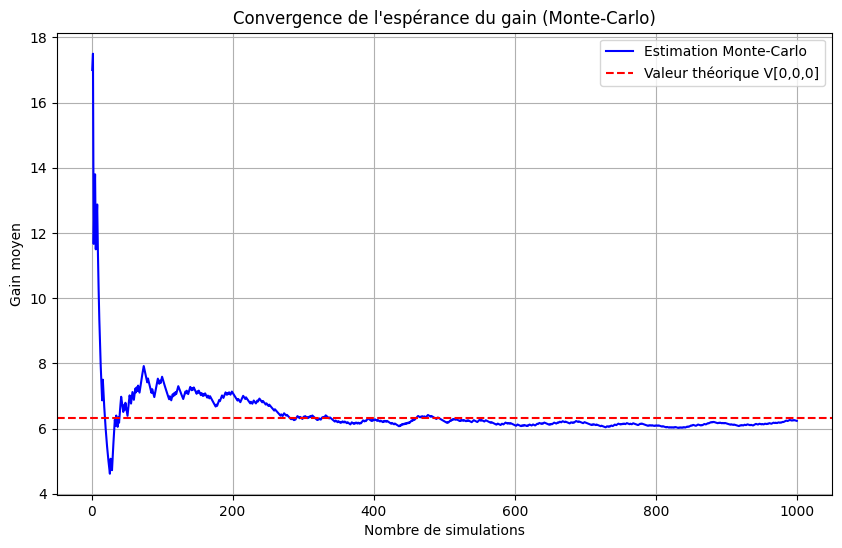

In [83]:
import matplotlib.pyplot as plt

def monte_carlo_with_plot(num_simulations, policy, actions, pair_array, V):
    gains = []
    cumulative_mean = []

    for i in range(1, num_simulations+1):
        lancers = simulation_lancers(100)
        x, y, z = simulation_player(lancers, policy, actions, pair_array, verbose=False)
        gain = x + y + z
        gains.append(gain)
        cumulative_mean.append(np.mean(gains))  # moyenne cumulative

    # Tracé
    plt.figure(figsize=(10,6))
    plt.plot(range(1, num_simulations+1), cumulative_mean, label="Estimation Monte-Carlo", color="blue")
    plt.axhline(y=V[0,0,0], color="red", linestyle="--", label="Valeur théorique V[0,0,0]")
    plt.xlabel("Nombre de simulations")
    plt.ylabel("Gain moyen")
    plt.title("Convergence de l'espérance du gain (Monte-Carlo)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return cumulative_mean

cumulative_mean = monte_carlo_with_plot(1000, policy, actions, pair_array, V)

In [8]:
import numpy as np
from numba import njit

OPEN = 7

def compute_probabilities() -> tuple[np.ndarray, np.ndarray]:
    pairs = {}
    for dice1 in range(1,7):
        for dice2 in range(1,7):
            for dice3 in range(1,7):
                for dice4 in range(1,7):
                    couples_get = (
                        tuple(sorted([dice1 + dice2, dice3 + dice4])),
                        tuple(sorted([dice1 + dice3, dice2 + dice4])),
                        tuple(sorted([dice1 + dice4, dice2 + dice3]))
                    )

                    if couples_get not in pairs:
                        pairs[couples_get] = 1/(6**4)
                    else:
                        pairs[couples_get] += 1/(6**4)

    pair_keys = list(pairs.keys())
    R = len(pair_keys)

    pair_array = np.zeros((R,3,2), dtype=np.int8)
    prob_array = np.zeros(R)

    for i,k in enumerate(pair_keys):
        for j in range(3):
            pair_array[i,j,0] = k[j][0]
            pair_array[i,j,1] = k[j][1]
        prob_array[i] = pairs[k]
    #print(pair_array[22])
    return pair_array, prob_array


def actions_from_roll_one_dimensional(pairings: list[tuple[int, int]], OPEN: int) -> list[int]:
    """ 
    Compute the possible actions (dx) from the 3 pairings, given the OPEN column:
    Stay, move 1 time, move 2 times. 
    """
    o = OPEN
    acts = set()
    for p1, p2 in pairings:
        dx = (1 if p1 == o else 0) + (1 if p2 == o else 0)
        if dx > 0:
            acts.add(dx)
    return list(acts)


def precompute_actions_one_dimensional(OPEN: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Builds a padded action array of shape (1296, 3) with -1 (because numba requires fixed size arrays).
    Each action is an integer in {0,1,2} representing how many times we can move on the line corresponding to OPEN."""
    pair_array, prob_array = compute_probabilities()
    R = pair_array.shape[0]
    Amax = 3 # max 3 actions possible (move 1, move 2, or stay)
    actions = -np.ones((R, Amax), dtype=np.int8)
    for r in range(R):
        pairings = (
            tuple(pair_array[r,0]),
            tuple(pair_array[r,1]),
            tuple(pair_array[r,2])
        )
        acts = actions_from_roll_one_dimensional(pairings, OPEN)
        if r==22:
            print(pairings, acts)

        for k in range(min(len(acts), Amax)):
            actions[r,k] = acts[k]
    return actions, pair_array, prob_array


@njit
def compute_V_one_dimensional(Nx: int, actions: np.ndarray, prob_array: np.ndarray):

    V = np.zeros(Nx + 1)
    V[Nx] = Nx
    policy = -np.ones((Nx + 1, actions.shape[0]), dtype=np.int8)
    stop, continu = 0, 0

    for x in range(Nx - 1, -1, -1):
        immediate_gain = x # if we stop
        future_gain = 0.0 
        for r in range(actions.shape[0]):
            best = 0.0
            a_best = -1 # if no admissible action, we lose and get 0
            for a in range(actions.shape[1]):
                dx = actions[r,a]
                if dx < 0: 
                    continue # no action for this roll
                nx = min(x + dx, Nx) # next state if we take this action (capped at Nx)
                val = V[nx] 
                if val > best: # we want to maximize our gain
                    best = val
                    a_best = dx
            policy[x, r] = a_best # store the best action for this state and roll
            future_gain += prob_array[r] * best # expected future gain if we keep going

        if immediate_gain >= future_gain: # we should stop
            V[x] = immediate_gain
            policy[x] = -1
            stop += 1
        else: # we should keep going
            V[x] = future_gain
            continu += 1

    return V, policy


In [9]:
def simulation_player_heuristic(lancers, 
                                  policy_3d, actions_3d, pair_array_3d,
                                  policies_1d, actions_1d, pair_array_1d,
                                  OPEN, alpha, Ns,
                                  verbose=False):
    """
    OPEN  = (o0, o1, o2) ex: (6, 7, 8)
    Ns    = dict {col: N_col} — nombre total de cases par colonne
    alpha = seuil de "presque remplie"
    policies_1d = dict {col: policy_1d} — une policy 1D par colonne
    actions_1d  = dict {col: actions_1d} — actions 1D par colonne
    """
    o0, o1, o2 = OPEN
    x, y, z = 0, 0, 0   # positions actuelles sur chaque colonne

    for lancer in lancers:
        d1, d2, d3, d4 = lancer

        # --- calcul du pairing et de l'index r (commun aux deux phases) ---
        pairings = np.array([
            sorted([d1+d2, d3+d4]),
            sorted([d1+d3, d2+d4]),
            sorted([d1+d4, d2+d3])
        ], dtype=np.int8)
        r = np.where(np.all(pair_array_3d == pairings, axis=(1,2)))[0]
        if len(r) == 0:
            if verbose: print("Pairing introuvable")
            return 0, 0, 0
        r = r[0]

        # --- cases restantes par colonne ---
        rem0 = Ns[o0] - x
        rem1 = Ns[o1] - y
        rem2 = Ns[o2] - z

        # --- détection d'une colonne presque remplie ---
        almost = None
        if   rem0 <= alpha: almost = (0, o0, x)
        elif rem1 <= alpha: almost = (1, o1, y)
        elif rem2 <= alpha: almost = (2, o2, z)

        if almost is not None:
            # --- PHASE 2 : policy 1D sur la colonne presque remplie ---
            idx, col, pos = almost
            acts_1d = actions_1d[col]
            pol_1d  = policies_1d[col]

            # vérifie qu'il existe au moins une action admissible
            nb_fail = np.sum(acts_1d[r] < 0)
            if nb_fail == acts_1d.shape[1]:
                if verbose: print("Phase 2 — aucune action possible, le joueur perd")
                return 0, 0, 0

            dx = pol_1d[pos, r]

            if dx == -1:
                # la policy 1D dit de s'arrêter
                if verbose: print(f"Phase 2 — stop sur colonne {col} en position {pos}")
                return int(x), int(y), int(z)

            new_pos = pos + dx
            if idx == 0: x = new_pos
            elif idx == 1: y = new_pos
            else:          z = new_pos

            if verbose:
                print(f"Phase 2 — dé: {lancer}, colonne {col}, dx={dx}, pos→{new_pos}")

            # colonne complétée ?
            if new_pos >= Ns[col]:
                if verbose: print(f"Colonne {col} complétée !")
                return int(x), int(y), int(z)

        else:
            # --- PHASE 1 : policy 3D ---
            acts_3d = actions_3d[r]
            nb_fail = np.sum(acts_3d[:, 0] < 0)
            if nb_fail == acts_3d.shape[0]:
                if verbose: print("Phase 1 — aucune action possible, le joueur perd")
                return 0, 0, 0

            lines_moved = policy_3d[x, y, z, r]

            if lines_moved[0] == -1:
                # la policy 3D dit de s'arrêter
                if verbose: print(f"Phase 1 — stop en ({x},{y},{z})")
                return int(x), int(y), int(z)

            x += lines_moved[0]
            y += lines_moved[1]
            z += lines_moved[2]

            if verbose:
                print(f"Phase 1 — dé: {lancer}, action: {lines_moved.tolist()}, pos→({x},{y},{z})")

    return int(x), int(y), int(z)

In [10]:
# Précalcul à faire une fois avant la simulation
Ns = {6: 11, 7: 13, 8: 11}   # nombre de cases par colonne (à adapter)
OPEN = (6, 7, 8)

policies_1d = {}
actions_1d_dict = {}

for col in OPEN:
    acts, pair_arr, prob_arr = precompute_actions_one_dimensional(col)
    V, pol = compute_V_one_dimensional(Ns[col], acts, prob_arr)
    policies_1d[col] = pol
    actions_1d_dict[col] = acts

# Précalcul 3D
actions_3d, pair_array_3d, prob_array_3d = precompute_actions(OPEN)
V_3d, policy_3d = compute_V(Ns[6], Ns[7], Ns[8], actions_3d, prob_array_3d)

((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
((np.int8(3), np.int8(4)), (np.int8(2), np.int8(5)), (np.int8(3), np.int8(4))) []
[-2 -2 -2]


In [11]:
def estimate_expected_gain_heuristic(num_simulations,
                                      policy_3d, actions_3d, pair_array_3d,
                                      policies_1d, actions_1d,
                                      OPEN, alpha, Ns):
    total_gain = 0
    for _ in range(num_simulations):
        lancers = simulation_lancers(100)
        x, y, z = simulation_player_heuristic(
            lancers,
            policy_3d, actions_3d, pair_array_3d,
            policies_1d, actions_1d, pair_array_3d,  # pair_array partagé
            OPEN, alpha, Ns
        )
        total_gain += x + y + z
    return total_gain / num_simulations

In [12]:
# Gain de la policy 3D pure
gain_3d = estimate_expected_gain(10000, policy_3d, actions_3d, pair_array_3d)

# Gain de l'heuristique pour différentes valeurs de alpha
for alpha in range(1, 6):
    gain_h = estimate_expected_gain_heuristic(
        10000,
        policy_3d, actions_3d, pair_array_3d,
        policies_1d, actions_1d_dict,
        OPEN, alpha, Ns
    )
    print(f"alpha={alpha} → gain heuristique = {gain_h:.4f}")

print(f"Policy 3D pure → gain = {gain_3d:.4f}")

alpha=1 → gain heuristique = 5.9710
alpha=2 → gain heuristique = 5.5956
alpha=3 → gain heuristique = 5.2568
alpha=4 → gain heuristique = 4.4588
alpha=5 → gain heuristique = 3.7066
Policy 3D pure → gain = 6.2728
